# 📊 Project 1: Exploratory Data Analysis (EDA) on a Public Dataset

**Dataset:** Titanic (publicly available)  
**Tools:** Python · Pandas · Matplotlib · Seaborn  

---


In [1]:
# ── Install / Import Libraries ────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
print("✅ Libraries loaded successfully!")


✅ Libraries loaded successfully!


## 1. Load Dataset

In [2]:
# Load Titanic dataset directly from URL
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print(f"Dataset Shape: {df.shape}")
df.head()


Dataset Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Dataset Overview

In [3]:
print("=" * 55)
print("COLUMNS & DATA TYPES")
print("=" * 55)
print(df.dtypes)

print("\n" + "=" * 55)
print("BASIC INFO")
print("=" * 55)
df.info()


COLUMNS & DATA TYPES
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

BASIC INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-

In [4]:
print("=" * 55)
print("DESCRIPTIVE STATISTICS")
print("=" * 55)
df.describe(include='all')


DESCRIPTIVE STATISTICS


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


## 3. Handle Missing Values

          Missing Count  Missing %
Age                 177      19.87
Cabin               687      77.10
Embarked              2       0.22


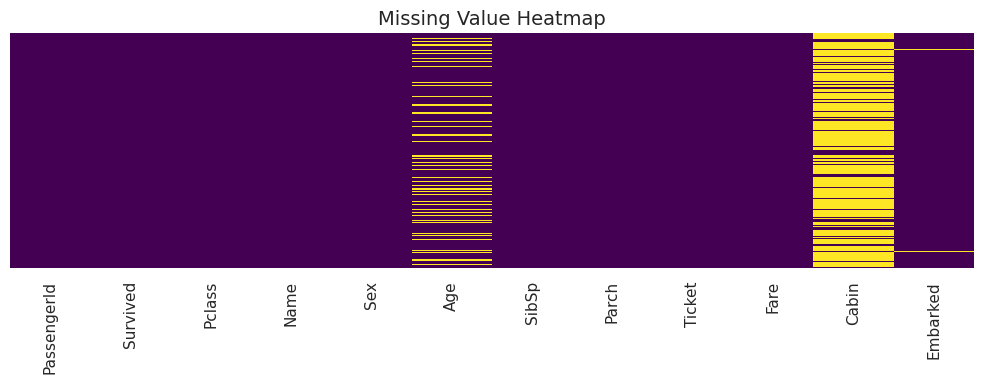

In [5]:
# ── Missing value summary ─────────────────────────────────────────────────────
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %'    : (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing[missing['Missing Count'] > 0])

# ── Visualise missing data ────────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing Value Heatmap", fontsize=14)
plt.tight_layout()
plt.show()


In [6]:
# ── Fill missing values ───────────────────────────────────────────────────────
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop(columns=['Cabin'], inplace=True)   # too many missing values

print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nDataset shape after cleaning:", df.shape)


Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Dataset shape after cleaning: (891, 11)


/tmp/ipykernel_6194/800293128.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_6194/800293128.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

## 4. Data Distributions

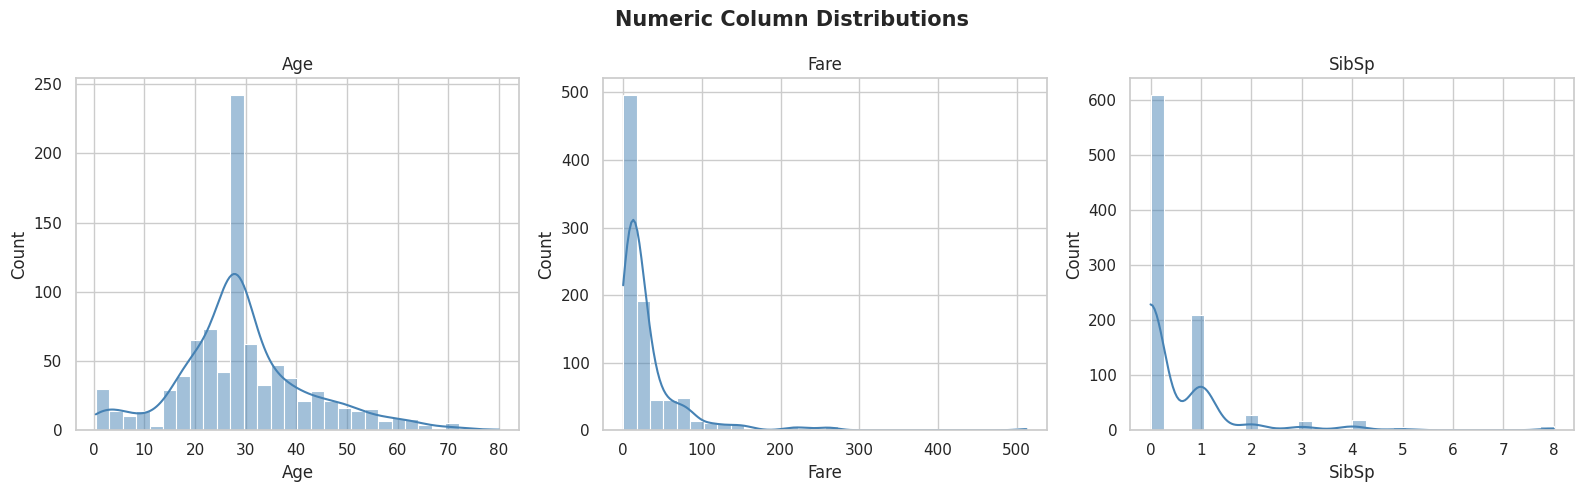

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Numeric Column Distributions", fontsize=15, fontweight='bold')

for ax, col in zip(axes, ['Age', 'Fare', 'SibSp']):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', bins=30)
    ax.set_title(col)

plt.tight_layout()
plt.show()


/tmp/ipykernel_6194/1604442198.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=ax, palette='Set2')
/tmp/ipykernel_6194/1604442198.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=ax, palette='Set2')
/tmp/ipykernel_6194/1604442198.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=ax, palette='Set2')


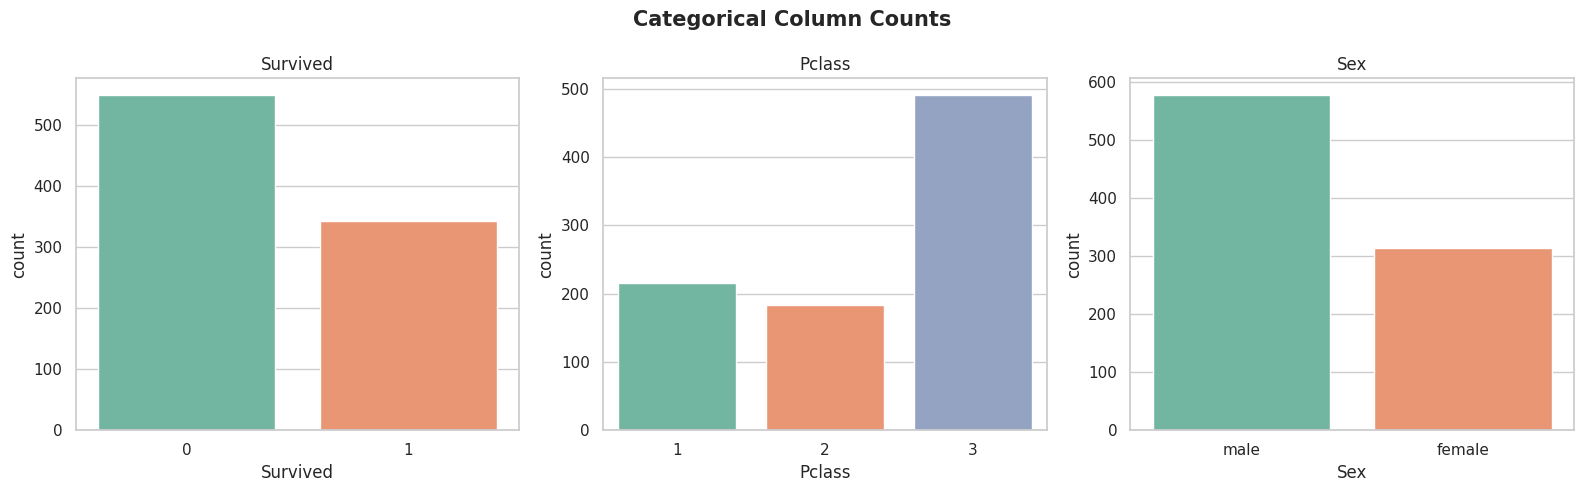

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Categorical Column Counts", fontsize=15, fontweight='bold')

for ax, col in zip(axes, ['Survived', 'Pclass', 'Sex']):
    sns.countplot(data=df, x=col, ax=ax, palette='Set2')
    ax.set_title(col)

plt.tight_layout()
plt.show()


## 5. Correlation Analysis

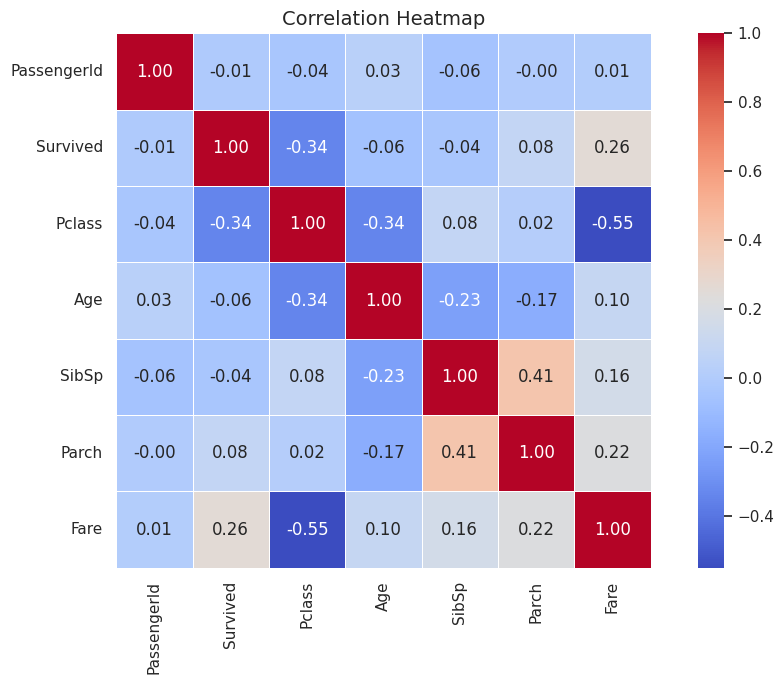

In [9]:
plt.figure(figsize=(10, 7))
num_cols = df.select_dtypes(include=[np.number])
sns.heatmap(num_cols.corr(), annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5, square=True)
plt.title("Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()


## 6. Key Patterns & Insights

/tmp/ipykernel_6194/3030011102.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Pclass', y='Fare',


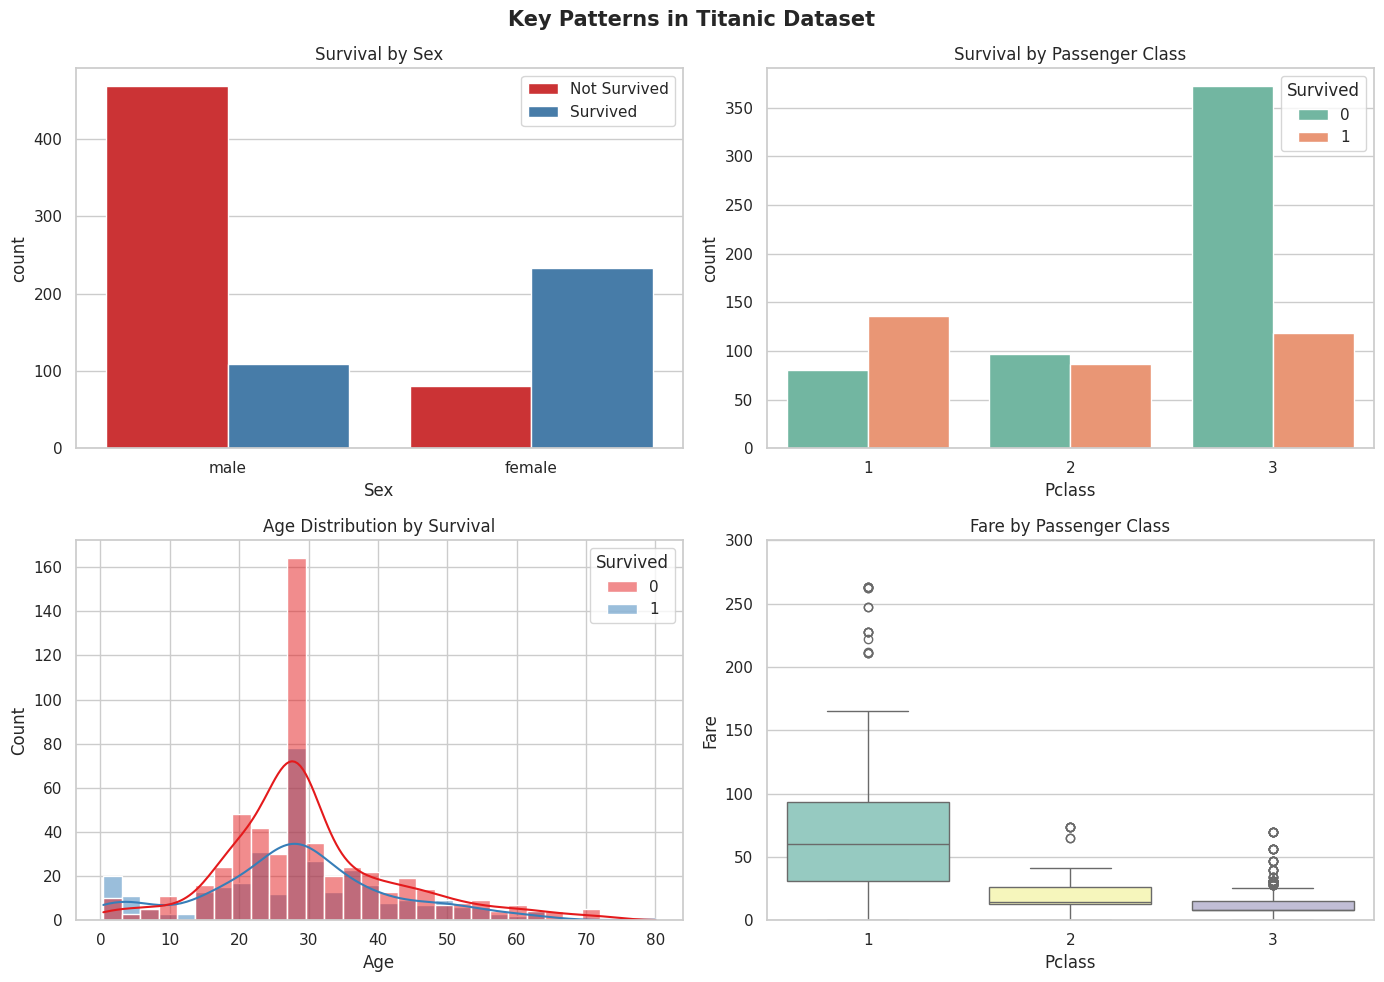

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Key Patterns in Titanic Dataset", fontsize=15, fontweight='bold')

# Survival by Sex
sns.countplot(data=df, x='Sex', hue='Survived',
              ax=axes[0,0], palette='Set1')
axes[0,0].set_title("Survival by Sex")
axes[0,0].legend(['Not Survived', 'Survived'])

# Survival by Passenger Class
sns.countplot(data=df, x='Pclass', hue='Survived',
              ax=axes[0,1], palette='Set2')
axes[0,1].set_title("Survival by Passenger Class")

# Age distribution by Survival
sns.histplot(data=df, x='Age', hue='Survived', kde=True,
             ax=axes[1,0], palette='Set1', bins=30)
axes[1,0].set_title("Age Distribution by Survival")

# Fare by Passenger Class
sns.boxplot(data=df, x='Pclass', y='Fare',
            ax=axes[1,1], palette='Set3')
axes[1,1].set_title("Fare by Passenger Class")
axes[1,1].set_ylim(0, 300)

plt.tight_layout()
plt.show()


In [11]:
# ── Summary Statistics ────────────────────────────────────────────────────────
print("=" * 55)
print("SURVIVAL RATE SUMMARY")
print("=" * 55)
print(f"Overall Survival Rate : {df['Survived'].mean()*100:.2f}%")
print(f"Female Survival Rate  : {df[df['Sex']=='female']['Survived'].mean()*100:.2f}%")
print(f"Male Survival Rate    : {df[df['Sex']=='male']['Survived'].mean()*100:.2f}%")
print(f"1st Class Survival    : {df[df['Pclass']==1]['Survived'].mean()*100:.2f}%")
print(f"3rd Class Survival    : {df[df['Pclass']==3]['Survived'].mean()*100:.2f}%")
print("\n✅ Project 1 – EDA Complete!")


SURVIVAL RATE SUMMARY
Overall Survival Rate : 38.38%
Female Survival Rate  : 74.20%
Male Survival Rate    : 18.89%
1st Class Survival    : 62.96%
3rd Class Survival    : 24.24%

✅ Project 1 – EDA Complete!
